In [1]:
import os

print(os.listdir("."))

['.ipynb_checkpoints', '.jupyter', 'classification.ipynb', 'E Commerce Dataset.xlsx', 'regression.ipynb']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel(
    "E Commerce Dataset.xlsx",
    sheet_name="E Comm"
)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Shape: (5630, 20)
Columns:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### Dataset Description

The dataset contains 5630 customer records and 20 attributes. The objective of the classification task is to predict customer churn.

**Target Variable:** Churn  
- 0 = Customer did not churn
- 1 = Customer churned

CustomerID is an identifier and is not used as a predictive feature.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check missing values and duplicates
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicates:", df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

# Remove duplicates
df = df.drop_duplicates()

# Remove CustomerID because it is only an identifier
df = df.drop(columns=["CustomerID"])

# Fill missing numerical values with median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 80:20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nX Shape:", X.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Missing Values:
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

Duplicates: 0

Churn Distribution:
Churn
0    4682
1     948
Name: count, dtype: int64

X Shape: (5630, 29)
X_train: (4504, 29)
X_test: (1126, 29)
y_train: (4504,)
y_test: (1126,)


### Data Preprocessing Observation

The dataset contains missing values in several numerical features such as Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount and DaySinceLastOrder.

Missing numerical values were replaced using the median. No duplicate records were found.

The target variable is imbalanced, with 4682 non-churn customers and 948 churn customers. Therefore, Weighted F1 Score is considered along with Accuracy when comparing the classification models.



In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC()
}

results = []
predictions = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    predictions[name] = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Weighted F1": weighted_f1
    })

    print(name)
    print("Accuracy:", round(accuracy, 4))
    print("Weighted F1:", round(weighted_f1, 4))
    print()

Logistic Regression
Accuracy: 0.889
Weighted F1: 0.8808

KNN
Accuracy: 0.897
Weighted F1: 0.8879

Gaussian Naive Bayes
Accuracy: 0.7043
Weighted F1: 0.7391

Decision Tree
Accuracy: 0.9663
Weighted F1: 0.9663

SVM
Accuracy: 0.9192
Weighted F1: 0.9125



### Confusion Matrix Observation

The confusion matrices show how well each classification model predicts churn and non-churn customers. Since the dataset is imbalanced, the models identify non-churn customers more easily than churn customers.

The confusion matrices should therefore be interpreted together with the Weighted F1 Score and Accuracy rather than relying only on Accuracy.

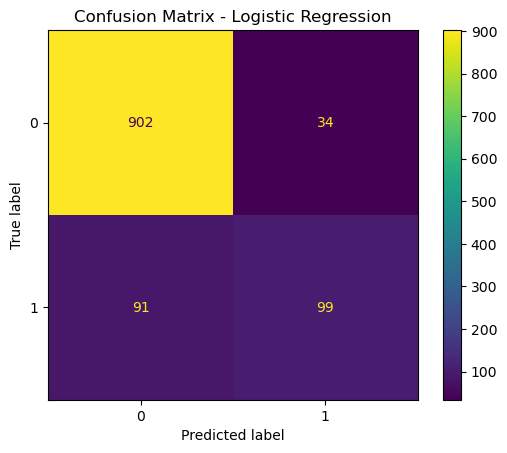

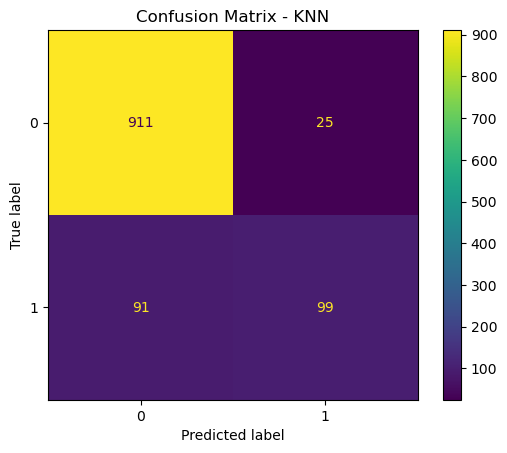

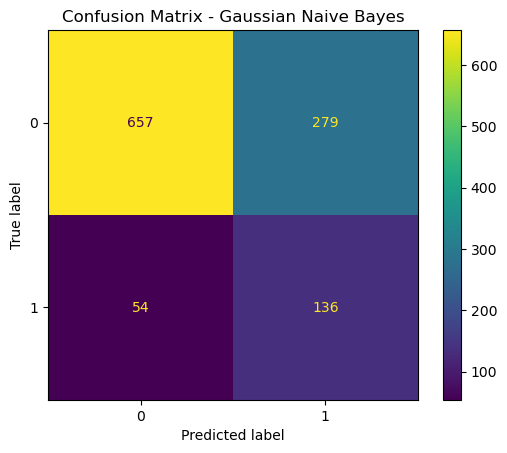

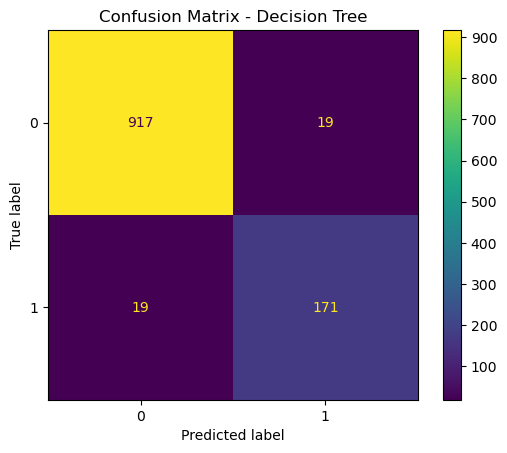

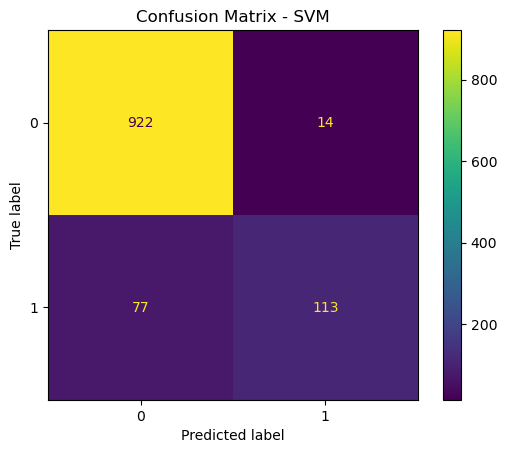

In [5]:
for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot()
    plt.title("Confusion Matrix - " + name)
    plt.show()

In [6]:
classification_results = pd.DataFrame(results)

classification_results = classification_results.sort_values(
    by="Weighted F1",
    ascending=False
).reset_index(drop=True)

classification_results.index += 1

classification_results.round(4)

,Model,Accuracy,Weighted F1
1,Decision Tree,0.9663,0.9663
2,SVM,0.9192,0.9125
3,KNN,0.8970,0.8879
4,Logistic Regression,0.8890,0.8808
5,Gaussian Naive Bayes,0.7043,0.7391


### Classification Part A - Observation

Five classification algorithms were evaluated for predicting customer churn using Accuracy and Weighted F1 Score.

Decision Tree achieved an Accuracy of 0.9663 and a Weighted F1 Score of 0.9663, which were the highest values among the five tested models. SVM achieved the next highest results with an Accuracy of 0.9192 and a Weighted F1 Score of 0.9125.

KNN and Logistic Regression also showed relatively strong performance, while Gaussian Naive Bayes produced lower performance compared with the other tested classifiers.

The confusion matrices were also examined to understand the classification performance for churn and non-churn customers.